# Avaliação Acadêmica - Selective Risk Framework
Esse notebook extrai os dados das execuções agregadas e gera gráficos no padrão acadêmico. Baseline vem de `outputs/final_eval/`; LAQDA (e variantes `laqda_sgr`) vêm de `outputs/final_eval_fixed/`, a árvore com o fix do bug de gradient checkpointing (`methods/laqda/models/encoder.py`) — ver célula de configuração (`BASE_DIR_BASELINE`/`BASE_DIR_LAQDA`).

In [ ]:
import os
os.environ.setdefault("OPENBLAS_NUM_THREADS", "4")
os.environ.setdefault("OMP_NUM_THREADS", "4")

import json
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display
import seaborn as sns

# Estilo acadêmico compartilhado por todos os gráficos deste notebook:
# fonte serifada (compatível com o corpo do artigo em LaTeX), grade leve
# apenas no eixo Y, sem bordas superior/direita, sem negrito em títulos.
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Liberation Serif", "Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.titleweight": "normal",
    "axes.labelsize": 11,
    "axes.labelweight": "normal",
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.color": "#dddddd",
    "grid.linewidth": 0.6,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "legend.frameon": False,
    "legend.fontsize": 9.5,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

# Paleta acadêmica consistente entre todos os gráficos deste notebook
# (evita cores "de dashboard" e mantém a mesma identidade visual do artigo)
PALETTE = {
    "laqda": "#2c7fb8",    # azul acadêmico -- método proposto
    "msp": "#d95f02",      # laranja terroso -- baseline de referência
    "accent": "#1b9e77",   # verde acinzentado -- destaque secundário
    "neutral": "#888888",  # cinza -- demais baselines
}
QUAL_PALETTE = ["#1b9e77", "#d95f02", "#7570b3", "#e7298a", "#66a61e", "#e6ab02",
                "#a6761d", "#666666", "#2c7fb8", "#b2182b"]

# Baseline não tem o bug de gradient checkpointing corrigido em
# methods/laqda/models/encoder.py (use_reentrant=True zerava o gradiente das
# camadas destravadas do BERT em todo treino LAQDA, inclusive com o Label-Aware
# ligado -- só o módulo Label-Aware em si aprendia) -- continua lido de
# final_eval/, sem precisar re-treinar. LAQDA e variantes (laqda_sgr) precisam
# ser re-treinados com o fix; esses resultados vivem numa árvore separada
# (final_eval_fixed/) para nunca misturar com os números antigos pré-fix.
# Ver scripts/run_all_pt.sh e scripts/compare.py (mesma convenção).
BASE_DIR_BASELINE = '../outputs/final_eval'
BASE_DIR_LAQDA = '../outputs/final_eval_fixed'
CORPUS = 'IntentPTCorpus' # Mude para o dataset desejado (ex: Banking77Corpus)
KSHOT = 'kshot_5'
LANG_DIR = 'br' # Use 'en' para datasets em inglês

# Métodos que entrarão no gráfico
METHODS = [
    ("MSP", "baseline", "msp"),
    ("Energy", "baseline", "energy"),
    ("Mahalanobis", "baseline", "mahalanobis"),
    ("kNN", "baseline", "knn"),
    ("ConjNorm", "baseline", "sota_conjnorm"),
    ("LAQDA", "laqda", ""),
    ("LAQDA+SGR", "laqda_sgr", ""),
    ("LAQDA+SGR (X-Maha)", "laqda_sgr", "xmaha")
]

In [ ]:
def load_aggregated_data(lang_dir, folder, corpus, kshot, suffix):
    # laqda/laqda_sgr sempre vão para a árvore pós-fix; baseline nunca precisa.
    base_path = BASE_DIR_LAQDA if folder.startswith("laqda") else BASE_DIR_BASELINE
    folds = [f"fold_0{i}" for i in range(1, 6)]
    metrics = {"accuracy": [], "aurc": [], "auroc": [], "sgr_coverage_at_risk_10": [], "fpr_at_95": []}
    
    for fold in folds:
        fname = "test_final_metrics_report.json" if suffix == "" else f"test_final_{suffix}_metrics_report.json"
        path = os.path.join(base_path, lang_dir, folder, corpus, fold, kshot, fname)
        if os.path.exists(path):
            with open(path) as f:
                d = json.load(f)
                for k in metrics.keys():
                    if k in d and d[k] is not None:
                        metrics[k].append(d[k])
    
    if not metrics['accuracy']:
        return None
        
    return {k: (np.mean(v), np.std(v)) for k, v in metrics.items() if v}

data_rows = []
for label, folder, suffix in METHODS:
    res = load_aggregated_data(LANG_DIR, folder, CORPUS, KSHOT, suffix)
    if res:
        data_rows.append({
            "Metodo": label,
            "ACC_mean": res.get('accuracy', (0,0))[0], "ACC_std": res.get('accuracy', (0,0))[1],
            "AURC_mean": res.get('aurc', (0,0))[0], "AURC_std": res.get('aurc', (0,0))[1],
            "AUROC_mean": res.get('auroc', (0,0))[0], "AUROC_std": res.get('auroc', (0,0))[1],
            "SGR10_mean": res.get('sgr_coverage_at_risk_10', (0,0))[0], "SGR10_std": res.get('sgr_coverage_at_risk_10', (0,0))[1],
            "FPR95_mean": res.get('fpr_at_95', (0,0))[0], "FPR95_std": res.get('fpr_at_95', (0,0))[1]
        })

df = pd.DataFrame(data_rows)
print(f"Dados carregados: {len(df)} métodos.")
display(df)

### Gráfico 1: Trade-off de Risco vs Cobertura (AURC vs SGR@10%)
Esse gráfico clássico de barras duplas demonstra como os métodos se saem ao equilibrar cobertura de dados e risco. Ideal para provar a eficácia do SGR.

In [ ]:
# B2WReviews é mais informativo que o CORPUS default (IntentPT) para este
# gráfico: no IntentPT, SGR@10% é ~0 para quase todos os métodos (ver
# Tabela tab:sgr do artigo), deixando a maior parte das barras de cobertura
# invisível. B2WReviews mostra a variação completa (MSP=0,77 a LAQDA=1,00).
CORPUS_SGR = "B2WReviewsCorpus"
rows_sgr = []
for label, folder, suffix in METHODS:
    res = load_aggregated_data(LANG_DIR, folder, CORPUS_SGR, KSHOT, suffix)
    if res:
        rows_sgr.append({
            "Metodo": label,
            "AURC_mean": res.get('aurc', (0,0))[0], "AURC_std": res.get('aurc', (0,0))[1],
            "SGR10_mean": res.get('sgr_coverage_at_risk_10', (0,0))[0], "SGR10_std": res.get('sgr_coverage_at_risk_10', (0,0))[1],
        })
df_sgr = pd.DataFrame(rows_sgr)

if not df_sgr.empty:
    fig, ax1 = plt.subplots(figsize=(7.2, 3.6))
    x = np.arange(len(df_sgr))
    width = 0.36

    ax1.bar(x - width/2, df_sgr['AURC_mean'], width, yerr=df_sgr['AURC_std'],
            label='AURC (↓)', color=PALETTE["msp"], alpha=0.85, capsize=3,
            error_kw={"elinewidth": 0.8, "capthick": 0.8})
    ax1.set_ylabel('AURC', color=PALETTE["msp"])
    ax1.tick_params(axis='y', labelcolor=PALETTE["msp"])
    ax1.set_ylim(bottom=0)

    ax2 = ax1.twinx()
    ax2.bar(x + width/2, df_sgr['SGR10_mean'], width, yerr=df_sgr['SGR10_std'],
            label='Cobertura SGR@10% (↑)', color=PALETTE["laqda"], alpha=0.85, capsize=3,
            error_kw={"elinewidth": 0.8, "capthick": 0.8})
    ax2.set_ylabel('Cobertura SGR@10%', color=PALETTE["laqda"])
    ax2.tick_params(axis='y', labelcolor=PALETTE["laqda"])
    ax2.set_ylim(bottom=0)
    ax2.grid(False)
    ax2.spines["top"].set_visible(False)

    ax1.set_xticks(x)
    ax1.set_xticklabels(df_sgr['Metodo'], rotation=25, ha='right')
    ax1.set_title(f'Risco vs. cobertura - {CORPUS_SGR.replace("Corpus","")} (5-shot)')

    fig.tight_layout()
    fig.savefig('plot_1_aurc_vs_sgr.pdf')
    plt.show()

### Gráfico 2: Detecção Out-of-Distribution (AUROC vs FPR@95)
Gráfico de dispersão (scatter) comparando a capacidade dos modelos de rejeitar dados OOD enquanto tentam aceitar os ID.

In [ ]:
# Eniac é o corpus com a maior margem OOD entre LAQDA e os baselines
# (Tabela tab:ood do artigo: +0,13 AUROC / -0,13 FPR@95), mais ilustrativo
# que o CORPUS default para este gráfico. Usa marcadores numerados + legenda
# em vez de rótulos inline, já que vários baselines ficam próximos no espaço
# FPR/AUROC e texto inline sobrepõe.
CORPUS_OOD = "EniacCorpus"
rows_ood = []
for label, folder, suffix in METHODS:
    res = load_aggregated_data(LANG_DIR, folder, CORPUS_OOD, KSHOT, suffix)
    if res and res.get('auroc') is not None:
        rows_ood.append({
            "Metodo": label,
            "AUROC_mean": res['auroc'][0], "AUROC_std": res['auroc'][1],
            "FPR95_mean": res['fpr_at_95'][0], "FPR95_std": res['fpr_at_95'][1],
        })
df_ood = pd.DataFrame(rows_ood).sort_values("AUROC_mean", ascending=False).reset_index(drop=True)

if not df_ood.empty:
    fig, ax = plt.subplots(figsize=(5.6, 4.6))
    for i, row in df_ood.iterrows():
        is_proposed = 'LAQDA' in row['Metodo']
        color = PALETTE["accent"] if is_proposed else PALETTE["neutral"]
        marker = 'D' if is_proposed else 'o'
        size = 7.5 if is_proposed else 6

        ax.errorbar(row['FPR95_mean'], row['AUROC_mean'],
                    xerr=row['FPR95_std'], yerr=row['AUROC_std'],
                    fmt=marker, markersize=size, color=color,
                    elinewidth=0.7, capsize=2, capthick=0.7, alpha=0.55, zorder=2)
        ax.scatter([row['FPR95_mean']], [row['AUROC_mean']], marker=marker,
                   s=size**2 * 1.6, color=color, zorder=3, edgecolors='white', linewidths=0.6)
        ax.annotate(str(i + 1), (row['FPR95_mean'], row['AUROC_mean']),
                    ha='center', va='center', fontsize=7, color='white',
                    fontweight='bold', zorder=4)

    legend_text = "\n".join(f"{i+1}. {m}" for i, m in enumerate(df_ood['Metodo']))
    ax.text(1.03, 0.98, legend_text, transform=ax.transAxes, fontsize=8.5,
            va='top', ha='left', linespacing=1.6)

    ax.set_xlabel('FPR@95% TPR (↓)')
    ax.set_ylabel('AUROC (↑)')
    ax.set_title(f'Separação ID/OOD - {CORPUS_OOD.replace("Corpus","")} (5-shot)')
    ax.invert_xaxis()
    ax.margins(x=0.2, y=0.2)

    fig.tight_layout()
    fig.savefig('plot_2_ood_detection.pdf')
    plt.show()

### Gráfico 3: AURC vs. Orçamento K (1/5/10-shot)
Reproduz os números da Tabela 2 do artigo (`tab:kshot`) a partir dos relatórios reais em `outputs/final_eval/`, para os quatro corpora usados na tabela: três em que o LAQDA se destaca (RePro, B2WReviews, Recognasumm) e o caso jurídico mais desafiador (RulingBR).

In [ ]:
KSHOT_CORPORA = ["ReProCorpus", "B2WReviewsCorpus", "RecognasummCorpus", "RulingBRCorpus"]
KSHOTS = ["kshot_1", "kshot_5", "kshot_10"]
K_LABELS = [1, 5, 10]

kshot_rows = []
for corpus in KSHOT_CORPORA:
    for kshot, k in zip(KSHOTS, K_LABELS):
        laqda_res = load_aggregated_data(LANG_DIR, "laqda", corpus, kshot, "")
        msp_res = load_aggregated_data(LANG_DIR, "baseline", corpus, kshot, "msp")
        if laqda_res:
            kshot_rows.append({"Corpus": corpus, "K": k, "Metodo": "LAQDA",
                                "AURC_mean": laqda_res["aurc"][0], "AURC_std": laqda_res["aurc"][1]})
        if msp_res:
            kshot_rows.append({"Corpus": corpus, "K": k, "Metodo": "MSP",
                                "AURC_mean": msp_res["aurc"][0], "AURC_std": msp_res["aurc"][1]})

df_kshot = pd.DataFrame(kshot_rows)
display(df_kshot)

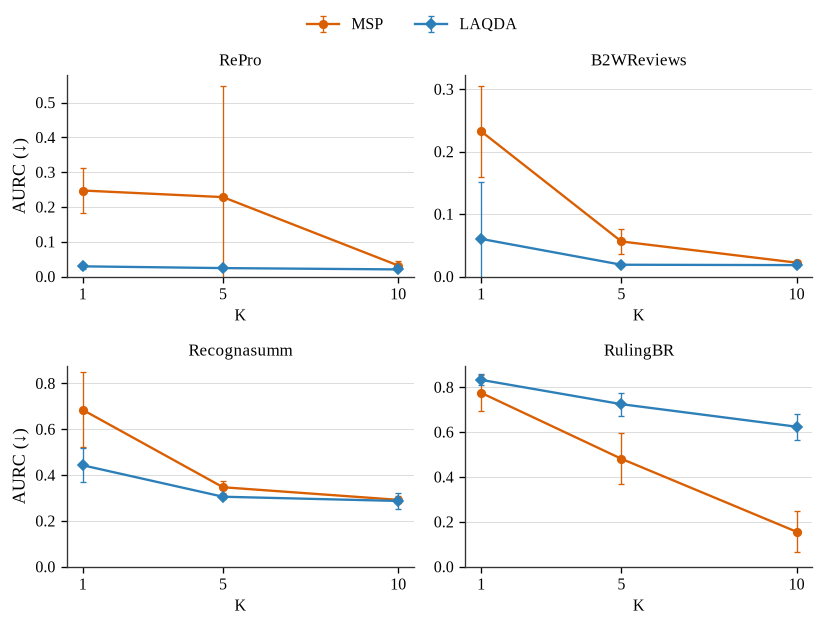

Figura salva em docs/figures/aurc_vs_kshot.{pdf,png}


In [23]:
if not df_kshot.empty:
    # 1. Muda para 2 linhas e 2 colunas, e ajusta a proporção da figura
    fig, axes = plt.subplots(2, 2, figsize=(7, 5), sharey=False)
    
    # 2. Achata a matriz de eixos para iterar facilmente no loop
    axes_flat = axes.flatten()
    
    colors = {"LAQDA": PALETTE["laqda"], "MSP": PALETTE["msp"]}
    markers = {"LAQDA": "D", "MSP": "o"}

    for ax, corpus in zip(axes_flat, KSHOT_CORPORA):
        sub = df_kshot[df_kshot["Corpus"] == corpus]
        for metodo in ["MSP", "LAQDA"]:
            s = sub[sub["Metodo"] == metodo].sort_values("K")
            if s.empty:
                continue
            ax.errorbar(s["K"], s["AURC_mean"], yerr=s["AURC_std"],
                        label=metodo, color=colors[metodo], marker=markers[metodo],
                        markersize=4.5, linewidth=1.4, capsize=2, elinewidth=0.8, capthick=0.8)
        ax.set_title(corpus.replace("Corpus", ""), fontsize=10)
        ax.set_xlabel("K", fontsize=9.5)
        ax.set_xticks(K_LABELS)
        ax.set_ylim(bottom=0)

    # 3. Adiciona o label Y nos gráficos da primeira coluna (índices 0 e 2)
    axes_flat[0].set_ylabel("AURC (\u2193)")
    axes_flat[2].set_ylabel("AURC (\u2193)")

    handles, labels = axes_flat[0].get_legend_handles_labels()
    # Ajustei levemente o bbox_to_anchor para acomodar o formato mais alto da imagem
    fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.05), frameon=False)
    fig.tight_layout()

    os.makedirs("../docs/figures", exist_ok=True)
    fig.savefig("../docs/figures/aurc_vs_kshot.pdf")
    fig.savefig("../docs/figures/aurc_vs_kshot.png")
    plt.show()
    print("Figura salva em docs/figures/aurc_vs_kshot.{pdf,png}")

### Gráfico 4: Emaranhamento de Classes no Domínio Jurídico (t-SNE + Silhueta)
Verificação direta da hipótese discutida na Seção de Discussão do artigo: textos jurídicos longos e formais (RulingBR, CourtDecision) diluiriam o sinal discriminativo no *pooling* via token `CLS`, produzindo classes mais emaranhadas no espaço do *encoder* do que em um domínio não jurídico comparável (Recognasumm, também com 10 classes). Usa os `test_features.pt`/`test_labels.pt` já cacheados do *encoder* `baseline` (pré-adaptação de rótulos) em `outputs/final_eval/`, sem exigir uma nova rodada de inferência em GPU.

In [ ]:
import json as _json
import torch
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics.pairwise import cosine_distances

with open('../configs/ood_splits.json') as f:
    OOD_SPLITS = _json.load(f)

TSNE_CORPORA = [
    ("RulingBRCorpus", "01", "Jurídico"),
    ("CourtDecisionCorpus", "01", "Jurídico"),
    ("RecognasummCorpus", "01", "Geral (não jurídico)"),
]

fig, axes = plt.subplots(1, 3, figsize=(9.5, 3.4))
tsne_results = {}

for ax, (corpus, fold, family) in zip(axes, TSNE_CORPORA):
    # Features do encoder BASELINE (não passou pelo bug do LAQDA -- ver
    # BASE_DIR_BASELINE/BASE_DIR_LAQDA na célula de configuração), continuam
    # válidas em final_eval/ sem re-rodar nada.
    feat_path = f"{BASE_DIR_BASELINE}/{LANG_DIR}/baseline/{corpus}/fold_{fold}/kshot_5/test_features.pt"
    lbl_path = f"{BASE_DIR_BASELINE}/{LANG_DIR}/baseline/{corpus}/fold_{fold}/kshot_5/test_labels.pt"
    features = torch.load(feat_path, map_location="cpu").numpy()
    labels = torch.load(lbl_path, map_location="cpu").numpy()

    mask = labels != -1  # descarta classes OOD reservadas; mantém apenas ID
    features, labels = features[mask], labels[mask]

    id_classes = OOD_SPLITS[corpus][fold]["id_classes"]

    # Índices de separabilidade calculados no espaço original de 768 dimensões,
    # antes da projeção 2D (a projeção t-SNE distorce distâncias e não deve ser
    # usada para métricas quantitativas). Silhueta usa cosseno (consistente com
    # o score geométrico do LAQDA); Davies-Bouldin/Calinski-Harabasz usam a
    # convenção euclidiana usual desses índices.
    sil = silhouette_score(features, labels, metric="cosine")
    db = davies_bouldin_score(features, labels)
    ch = calinski_harabasz_score(features, labels)

    uniq = np.unique(labels)
    centroids = np.stack([features[labels == c].mean(0) for c in uniq])
    intra = np.mean([cosine_distances(features[labels == c], [centroids[i]]).mean()
                      for i, c in enumerate(uniq)])
    inter = cosine_distances(centroids).sum() / (len(centroids) * (len(centroids) - 1))

    tsne_results[corpus] = {
        "silhouette_cosine": float(sil), "davies_bouldin": float(db),
        "calinski_harabasz": float(ch), "intra_dist_cosine": float(intra),
        "inter_dist_cosine": float(inter), "n_classes": len(id_classes),
        "n_examples": int(mask.sum()),
    }

    proj = TSNE(n_components=2, perplexity=30, random_state=42, init="pca").fit_transform(features)

    for i, cname in enumerate(id_classes):
        sel = labels == i
        if sel.sum() == 0:
            continue
        ax.scatter(proj[sel, 0], proj[sel, 1], s=6, alpha=0.55,
                  color=QUAL_PALETTE[i % len(QUAL_PALETTE)], linewidths=0)

    ax.set_title(f"{corpus.replace('Corpus','')} ({family})\nsilhueta (cosseno) = {sil:.3f}", fontsize=9.5)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("#cccccc")

fig.tight_layout()
os.makedirs("../docs/figures", exist_ok=True)
fig.savefig("../docs/figures/tsne_legal_domain.pdf")
fig.savefig("../docs/figures/tsne_legal_domain.png")
plt.show()

display(pd.DataFrame(tsne_results).T)
print("Figura salva em docs/figures/tsne_legal_domain.{pdf,png}")
print("Números usados na Tabela tab:cluster_metrics do artigo (docs/paper.tex).")